In [ ]:
################################
import xarray as xr 
import pandas as pd
import numpy  as np

import seaborn as sns 

import os


In [ ]:
################################
# Set the working directory
DATAPATH = '/Users/hao/EXTERNAL/PROGRESS/Carbon_Recovery_and_Climate'
WORKPATH = '/Users/hao/01-RESEARCH/PROGRESS/Carbon_Recovery_and_Climate'

cmip_models = [
    'ACCESS-ESM1-5',
    'CanESM5', 
    'CESM2',
    'CESM2-FV2',
    'CESM2-WACCM',
    'CESM2-WACCM-FV2',
    'CMCC-CM2-SR5',
    'CMCC-ESM2',
    #'E3SM-1-1',
    #'E3SM-1-1-ECA',
    'EC-Earth3-CC',
    'EC-Earth3-Veg-LR',
    'GFDL-ESM4',
    #'GISS-E2-1-G-CC',
    #'GISS-E2-2-H',
    'INM-CM4-8',
    'INM-CM5-0',
    'IPSL-CM5A2-INCA',
    'IPSL-CM6A-LR',
    'IPSL-CM6A-LR-INCA',
    'MPI-ESM-1-2-HAM',
    'MPI-ESM1-2-LR',
    'NorESM2-LM',
    'NorESM2-MM',
    'SAM0-UNICON',
    'TaiESM1'
]


# NBP


In [ ]:
################################

#---- Function to convert NBP units ----
def convert_nbp_units(nbp_data):
    """
    Convert NBP from kg m^{-2} s^{-1} to Gt C month^{-1}.
    """
    # Seconds per month
    seconds = xr.DataArray(
        pd.to_datetime(nbp_data.time.values).days_in_month * 24 * 3600,
        coords=[nbp_data.time], dims=['time']
    )
    nbp_month = nbp_data * seconds

    # Grid cell area (m²)
    R = 6.371e6
    lat_rad = np.radians(nbp_data.lat)
    dlat = np.abs(lat_rad.diff('lat')[0])
    dlon = np.abs(np.radians(nbp_data.lon).diff('lon')[0])
    area = (R**2) * dlat * dlon * np.cos(lat_rad)
    area_2d = area * xr.ones_like(nbp_data.lon)

    # Convert to Gt C month^{−1}
    nbp_gtc = nbp_month * area_2d / 1e12
    nbp_gtc.attrs.update({'units': 'Gt C month^{-1}', 'long_name': 'Net Biospheric Production in Gt C per month'})
    return nbp_gtc

#---Process CMIP NBP data for multiple models---
cmip_data_dir  = f'{DATAPATH}/01-data/CMIP/CMIP6/historical/'
var, table = 'nbp', 'Lmon'
all_timeseries = {}

for model in cmip_models:

    file_name = f'{cmip_data_dir}/{table}/{var}/{model}/{var}_{table}_{model}_historical_1deg.nc'
    ds = xr.open_dataset(file_name)[var]
    # Select the tropics (23.5°S to 23.5°N)
    ds_tropics = ds.sel(lat=slice(-23.5, 23.5))
    # Convert units from kg m^{-2} s^{-1} to Gt C month^{-1}
    ds_tropics = convert_nbp_units(ds_tropics)
    # Calculate the area-weighted sum
    weights = np.cos(np.radians(ds_tropics.lat)) * xr.ones_like(ds_tropics.lon)
    all_timeseries[model] = ds_tropics.weighted(weights).sum(dim=['lat', 'lon'], skipna=True) #! Sum for NBP

    print(f"✅ Processing model: {model}")

# Combine to DataFrame
df_nbp = pd.DataFrame({m: ts.to_pandas() for m, ts in all_timeseries.items()})

#--- Save the DataFrame to a CSV file
df_nbp.to_csv(f'{WORKPATH}/01-data/nbp_CMIP.csv')


✅ Processing model: ACCESS-ESM1-5
✅ Processing model: CanESM5
✅ Processing model: CESM2
✅ Processing model: CESM2-FV2
✅ Processing model: CESM2-WACCM
✅ Processing model: CESM2-WACCM-FV2
✅ Processing model: CMCC-CM2-SR5
✅ Processing model: CMCC-ESM2
✅ Processing model: EC-Earth3-CC
✅ Processing model: EC-Earth3-Veg-LR
✅ Processing model: GFDL-ESM4
✅ Processing model: INM-CM4-8
✅ Processing model: INM-CM5-0
✅ Processing model: IPSL-CM5A2-INCA
✅ Processing model: IPSL-CM6A-LR
✅ Processing model: IPSL-CM6A-LR-INCA
✅ Processing model: MPI-ESM-1-2-HAM
✅ Processing model: MPI-ESM1-2-LR
✅ Processing model: NorESM2-LM
✅ Processing model: NorESM2-MM
✅ Processing model: SAM0-UNICON
✅ Processing model: TaiESM1


<Axes: >

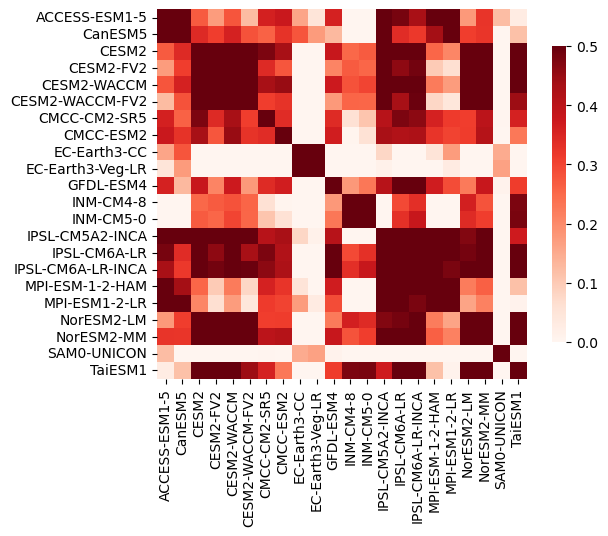

In [ ]:
# calculate the correlation and heatmap plot
df_nbp.corr()

sns.heatmap(df_nbp.corr(), cmap='Reds', square=True, vmin=0, vmax=0.5, cbar_kws={"shrink": .8})


# TOS


In [ ]:
########################

#---Process CMIP SST data for multiple models---
cmip_data_dir  = f'{DATAPATH}/01-data/CMIP/CMIP6/historical/'
var, table = 'tos', 'Omon'
all_timeseries = {}

for model in cmip_models:
    
    file_name = f'{cmip_data_dir}/{table}/{var}/{model}/{var}_{table}_{model}_historical_1deg.nc'
    ds = xr.open_dataset(file_name)[var]
    # Select the Nino3.4 region (5°S to 5°N, 170°W to 120°W)
    ds_nina34 = ds.sel(lat=slice(-5, 5), lon=slice(-170, -120))
    # Calculate the area-weighted mean SST for Nino3.4
    lat_weights = np.cos(np.radians(ds_nina34.lat)) * xr.ones_like(ds_nina34.lon)
    nino34_mean = ds_nina34.weighted(lat_weights).mean(dim=['lat', 'lon'], skipna=True)
    # Calculate the monthly anomalies
    climatology = nino34_mean.groupby('time.month').mean()
    all_timeseries[model] = nino34_mean.groupby('time.month') - climatology

    print(f"✅ Processing model: {model}")

# Combine to DataFrame
df_nina34 = pd.DataFrame({m: ts.to_pandas() for m, ts in all_timeseries.items()})

df_nina34 = df_nina34.loc[df_nina34.index <= '2014-12-31']

#--- Save the DataFrame to a CSV file
df_nina34.to_csv(f'{WORKPATH}/01-data/nina34_CMIP.csv')


✅ Processing model: ACCESS-ESM1-5
✅ Processing model: CanESM5
✅ Processing model: CESM2
✅ Processing model: CESM2-FV2
✅ Processing model: CESM2-WACCM
✅ Processing model: CESM2-WACCM-FV2
✅ Processing model: CMCC-CM2-SR5
✅ Processing model: CMCC-ESM2
✅ Processing model: EC-Earth3-CC
✅ Processing model: EC-Earth3-Veg-LR
✅ Processing model: GFDL-ESM4
✅ Processing model: INM-CM4-8
✅ Processing model: INM-CM5-0
✅ Processing model: IPSL-CM5A2-INCA
✅ Processing model: IPSL-CM6A-LR
✅ Processing model: IPSL-CM6A-LR-INCA
✅ Processing model: MPI-ESM-1-2-HAM
✅ Processing model: MPI-ESM1-2-LR
✅ Processing model: NorESM2-LM
✅ Processing model: NorESM2-MM
✅ Processing model: SAM0-UNICON
✅ Processing model: TaiESM1


# MRSO


In [ ]:
################################

#---Process CMIP soil moisture for multiple models---
cmip_data_dir  = f'{DATAPATH}/01-data/CMIP/CMIP6/historical/'
var, table = 'mrso', 'Lmon'
all_timeseries = {}

for model in cmip_models:
    print(f"Processing model: {model}")
    file_name = f'{cmip_data_dir}/{table}/{var}/{model}/{var}_{table}_{model}_historical_1deg.nc'
    ds = xr.open_dataset(file_name)[var]
    # Select the tropics (23.5°S to 23.5°N)
    ds_tropics = ds.sel(lat=slice(-23.5, 23.5))
    # Calculate the area-weighted mean
    weights = np.cos(np.radians(ds_tropics.lat)) * xr.ones_like(ds_tropics.lon)
    all_timeseries[model] = ds_tropics.weighted(weights).mean(dim=['lat', 'lon'], skipna=True) #! Mean for soil moisture

# Combine to DataFrame
df_mrso = pd.DataFrame({m: ts.to_pandas() for m, ts in all_timeseries.items()})

#--- Save the DataFrame to a CSV file
df_mrso.to_csv(f'{WORKPATH}/01-data/mrso_CMIP.csv')


Processing model: ACCESS-ESM1-5
Processing model: CanESM5
Processing model: CESM2
Processing model: CESM2-FV2
Processing model: CESM2-WACCM
Processing model: CESM2-WACCM-FV2
Processing model: CMCC-CM2-SR5
Processing model: CMCC-ESM2
Processing model: EC-Earth3-CC
Processing model: EC-Earth3-Veg-LR
Processing model: GFDL-ESM4
Processing model: INM-CM4-8
Processing model: INM-CM5-0
Processing model: IPSL-CM5A2-INCA
Processing model: IPSL-CM6A-LR
Processing model: IPSL-CM6A-LR-INCA
Processing model: MPI-ESM-1-2-HAM
Processing model: MPI-ESM1-2-LR
Processing model: NorESM2-LM
Processing model: NorESM2-MM
Processing model: SAM0-UNICON
Processing model: TaiESM1


# fgCO2


In [ ]:
################################

#---Process CMIP fgCO2 data for multiple models---
cmip_data_dir  = f'{DATAPATH}/01-data/CMIP/CMIP6/historical/'
var, table = 'fgco2', 'Omon'
all_timeseries = {}

for model in cmip_models:

    file_name = f'{cmip_data_dir}/{table}/{var}/{model}/{var}_{table}_{model}_historical_1deg.nc'

    if not os.path.exists(file_name):
        print(f"⚠️  No data for {model}, filling with NaN")
        all_timeseries[model] = None
        continue

    try:
        ds = xr.open_dataset(file_name)[var]
        # Remove duplicate time steps (common in merged CMIP6 files)
        _, idx = np.unique(ds.time.values, return_index=True)
        ds = ds.isel(time=idx)
        # Clip to historical period only
        ds = ds.sel(time=slice('1850-01', '2014-12'))
        # Select the tropics (23.5°S to 23.5°N) — ocean only (land cells are NaN)
        ds_tropics = ds.sel(lat=slice(-23.5, 23.5))
        # Convert units from kg m^{-2} s^{-1} to Gt C month^{-1}
        ds_tropics = convert_nbp_units(ds_tropics)
        # Area-weighted sum over ocean grid cells (NaN land cells are skipped)
        weights = np.cos(np.radians(ds_tropics.lat)) * xr.ones_like(ds_tropics.lon)
        all_timeseries[model] = ds_tropics.weighted(weights).sum(dim=['lat', 'lon'], skipna=True).to_pandas()
        print(f"✅ Processing model: {model}")

    except Exception as e:
        print(f"❌ Error processing {model}: {e}")
        all_timeseries[model] = None

# Combine to DataFrame (models without data become NaN columns)
df_fgco2 = pd.DataFrame(all_timeseries)

#--- Save the DataFrame to a CSV file
df_fgco2.to_csv(f'{WORKPATH}/01-data/fgco2_CMIP.csv')
print(f"fgco2_CMIP.csv saved ({df_fgco2.notna().any().sum()}/{len(cmip_models)} models with data).")


✅ Processing model: ACCESS-ESM1-5
✅ Processing model: CanESM5
✅ Processing model: CESM2
✅ Processing model: CESM2-FV2
✅ Processing model: CESM2-WACCM
✅ Processing model: CESM2-WACCM-FV2
⚠️  No data for CMCC-CM2-SR5, filling with NaN
✅ Processing model: CMCC-ESM2
✅ Processing model: EC-Earth3-CC
⚠️  No data for EC-Earth3-Veg-LR, filling with NaN
✅ Processing model: GFDL-ESM4
✅ Processing model: INM-CM4-8
✅ Processing model: INM-CM5-0
✅ Processing model: IPSL-CM5A2-INCA
✅ Processing model: IPSL-CM6A-LR
✅ Processing model: IPSL-CM6A-LR-INCA
✅ Processing model: MPI-ESM-1-2-HAM
✅ Processing model: MPI-ESM1-2-LR
✅ Processing model: NorESM2-LM
✅ Processing model: NorESM2-MM
⚠️  No data for SAM0-UNICON, filling with NaN
⚠️  No data for TaiESM1, filling with NaN
fgco2_CMIP.csv saved (18/22 models with data).


# Validate land and ocean carbon flux


In [ ]:
df_nbp   = pd.read_csv('../../../01-data/nbp_CMIP.csv',   index_col=0, parse_dates=True)
df_fgco2 = pd.read_csv('../../../01-data/fgco2_CMIP.csv', index_col=0, parse_dates=True)

df_tot = df_nbp.add(df_fgco2, fill_value=0) 
df_tot.to_csv(f'{WORKPATH}/01-data/total_carbon_flux_CMIP.csv')


In [ ]:
df_tot_year = df_tot.resample('YE').sum()
df_nbp_year = df_nbp.resample('YE').sum()
df_fgco2_year = df_fgco2.resample('YE').sum()


In [ ]:
df_tot_year_var = df_tot_year.var() 
df_nbp_year_var = df_nbp_year.var()
df_fgco2_year_var = df_fgco2_year.var() 


/var/folders/4p/mzjwz8hd08b894cfbvtrv6w80000gn/T/ipykernel_83227/4247883588.py:124: UltraPlotWarning: fig.subplots_adjust() has no effect on ultraplot figures. To set the left, right, bottom, top, wspace, or hspace gridspec values, pass them as keyword arguments to uplt.figure() or uplt.subplots(). Please note they are now specified in physical units, with strings interpreted by uplt.units() and floats interpreted as font size-widths.
  fig.subplots_adjust(hspace=0.15)


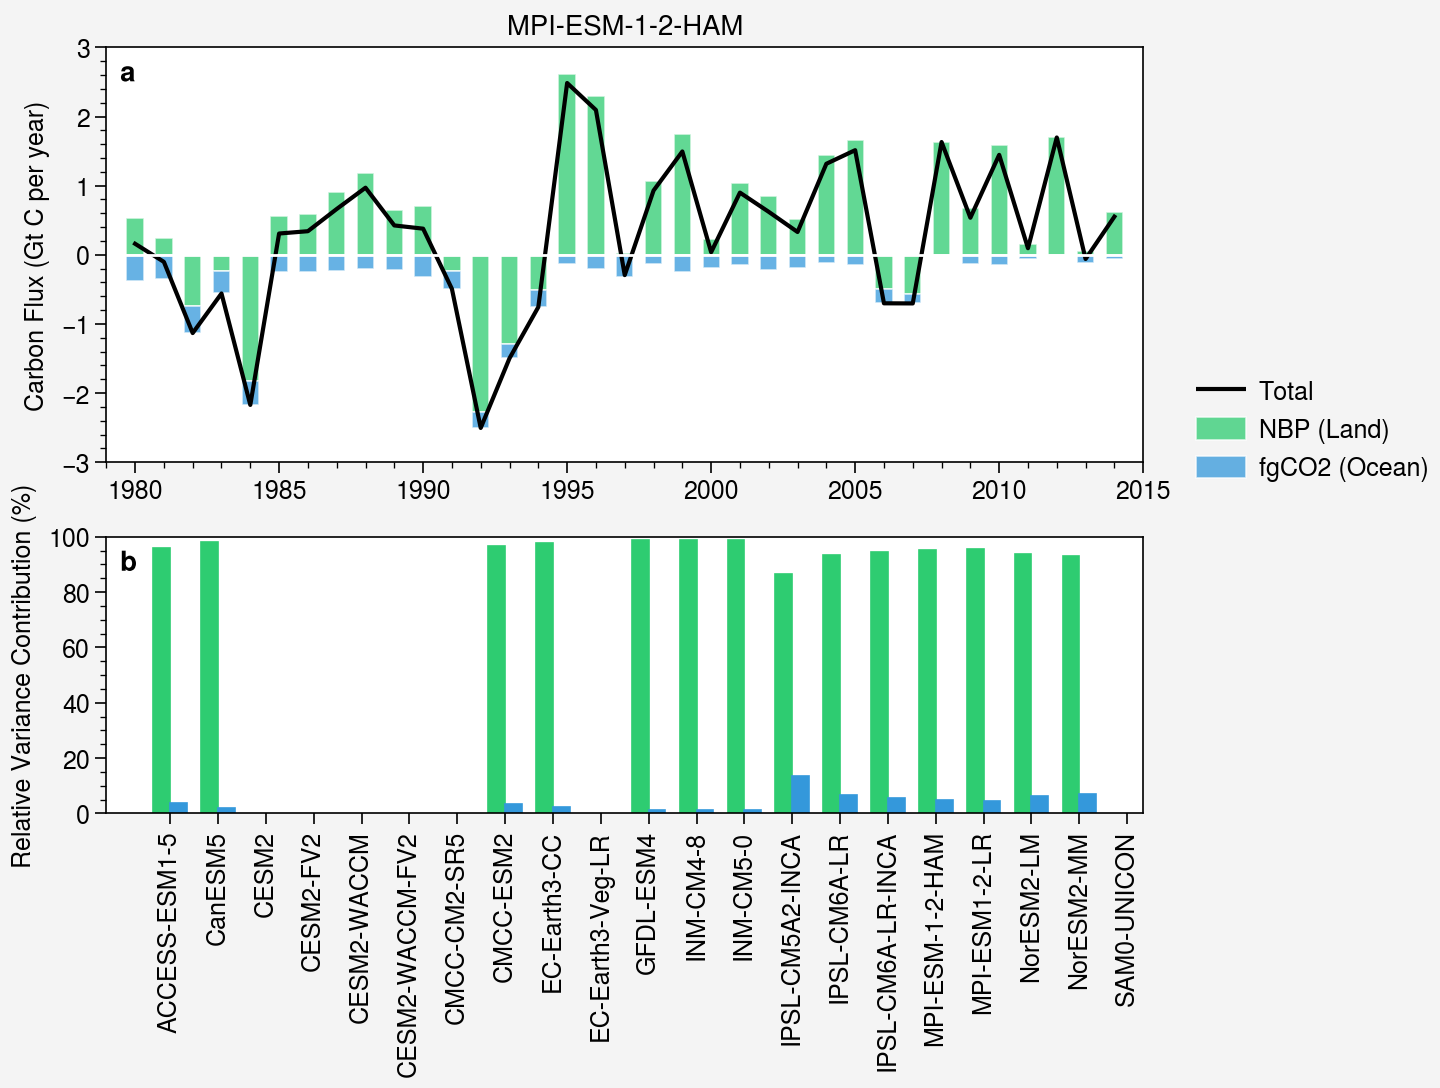

In [ ]:
# --- Combined figure: Upper panel (time series) + Lower panel (model comparison) ---
import ultraplot as pplt
import numpy as np
import pandas as pd

# ============================================================
# Data preparation (assuming df_nbp_year, df_fgco2_year, df_tot_year, df_nbp_year_var, df_fgco2_year_var exist)
# ============================================================

# ---- Upper panel: Single model time series (1980-2014) ----
model = 'MPI-ESM-1-2-HAM'

nbp = df_nbp_year.loc['1980':'2014', model].values
fgco2 = df_fgco2_year.loc['1980':'2014', model].values
tot = df_tot_year.loc['1980':'2014', model].values
years = df_nbp_year.loc['1980':'2014'].index.year.values

# Prepare data for plotting stacked bars
data = np.zeros([2, len(nbp)]) * np.nan
data[0, :] = nbp
data[1, :] = fgco2
data_shape = np.shape(data)

def get_cumulated_array(data, **kwargs):
    # Take negative and positive data apart and cumulate
    cum = data.clip(**kwargs)
    cum = np.cumsum(cum, axis=0)
    d = np.zeros(np.shape(data))
    d[1:] = cum[:-1]
    return d

# Cumulated values
cumulated_data = get_cumulated_array(data, min=0)
cumulated_data_neg = get_cumulated_array(data, max=0)

# Re-merge negative and positive data
row_mask = (data < 0)
cumulated_data[row_mask] = cumulated_data_neg[row_mask]
data_stack = cumulated_data

# ---- Lower panel: Multi-model relative variance contributions ----
models = df_nbp_year_var.index
land_variance = df_nbp_year_var
ocean_variance = df_fgco2_year_var

ocean_variance = ocean_variance.replace(0, np.nan)
land_variance = land_variance.replace(0, np.nan)

# Calculate relative contributions (NaN if missing)
land_rel = land_variance.values
ocean_rel = ocean_variance.values
total_abs = np.abs(land_rel) + np.abs(ocean_rel)
land_contrib = np.where(~np.isnan(total_abs), land_rel / total_abs * 100, np.nan)
ocean_contrib = np.where(~np.isnan(total_abs), ocean_rel / total_abs * 100, np.nan)

x_models = np.arange(len(models))
bar_width = 0.35

# ============================================================
# Create figure with 2 stacked subplots
# ============================================================
fig, axs = pplt.subplots(nrows=2, ncols=1, refaspect=2.5, journal="nat2", sharex=False, height_ratios=[1.5, 1], share=0)

# ----- Upper panel (axs[0]): Time series -----
ax = axs[0]
x_time = years
width = 0.6

# Stacked bar plot with proper positive/negative handling
colors = ['#2ecc71', '#3498db']
labels = ['NBP (Land)', 'fgCO2 (Ocean)']
for j in np.arange(0, data_shape[0]):
    ax.bar(x_time, data[j], bottom=data_stack[j], color=colors[j], width=width, 
           label=labels[j], edgecolor='w', alpha=0.75)

# Overlay total flux line
ax.plot(x_time, tot, color='black', linewidth=1.5, label='Total', marker='o', markersize=0)

# Zero reference line
ax.axhline(y=0, color='w', linestyle='-', linewidth=1, alpha=1)

ax.format(
    title=f'{model}',
    ylabel='Carbon Flux (Gt C per year)',
    xlabel=None,  # No x-label for upper panel
    grid=False,
    ylim=(-3, 3),
    xlim=(1979, 2015)
)

# ----- Lower panel (axs[1]): Model comparison -----
ax = axs[1]

ax.bar(x_models - bar_width/2, land_contrib, width=bar_width, 
       label='Land (NBP)', color='#2ecc71')
ax.bar(x_models + bar_width/2, ocean_contrib, width=bar_width, 
       label='Ocean (fgCO2)', color='#3498db')

ax.format(
    ylabel='Relative Variance Contribution (%)',
    xlocator=x_models,
    xticklabels=models.to_list(),
    xrotation=90,
    grid=False,
    ylim=(0, 100)
)

# ----- Shared legend (placed outside, right side) -----
# Collect handles and labels from both panels
handles1, labels1 = axs[0].get_legend_handles_labels()
handles2, labels2 = axs[1].get_legend_handles_labels()

# Combine (avoid duplicates)
all_handles = handles1 #+ handles2
all_labels = labels1 #+ labels2

# Place legend on the right side, spanning both panels
fig.legend(all_handles, all_labels, loc='r', ncols=1, frameon=False)

# Adjust layout
fig.format(abc='a', abcloc='ul')  # Add panel labels (a) and (b)

# Optional: Add horizontal spacing between panels
fig.subplots_adjust(hspace=0.15)


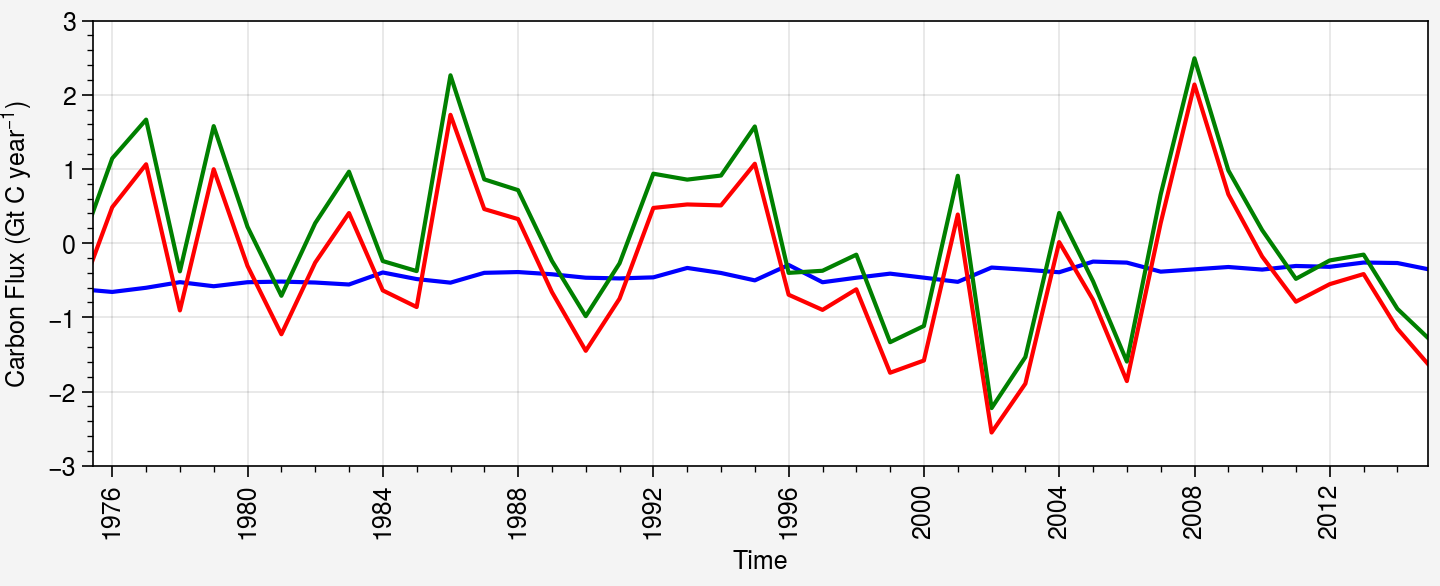

In [ ]:
df_fgco2_1_yr = df_fgco2_1.resample('YE').sum()
df_nbp_1_yr = df_nbp_1.resample('YE').sum()

fig, ax = pplt.subplots(ncols=1, nrows=1, journal="nat2", refaspect=3)

ax.plot(df_fgco2_1_yr.index, df_fgco2_1_yr.values, label='fgCO$_2$ (Gt C year$^{-1}$)', color='blue')

ax.plot(df_nbp_1_yr.index, df_nbp_1_yr.values, label='NBP (Gt C year$^{-1}$)', color='green')

ax.plot(df_nbp_1_yr.index, (df_nbp_1_yr + df_fgco2_1_yr).values, label='Total (Gt C year$^{-1}$)', color='red')

ax.format(xlabel='Time', ylabel='Carbon Flux (Gt C year$^{-1}$)',  ylim=(-3, 3), xformatter='%Y', xlim=(1980, df_nbp_1.index.max()), )
